# GPT Text Generation: Local GPT-2 and the OpenAI API

## 📚 Learning Objectives

By completing this notebook, you will:
- **Generate real text with a GPT model (GPT-2) running locally** via Hugging Face — no API key needed
- Compare **greedy decoding vs. sampling**, and see how **temperature** changes the generated text
- Understand basic **prompt engineering** ideas
- See how commercial APIs (OpenAI) scale the same idea up — as a **code walkthrough, not executed here**
  (running it requires a paid OpenAI account and API key)

## 🔗 Where this fits

**Builds on:** Course 07 — Unit 4, lesson 01 "Attention and Transformers" — the causal mask introduced there is exactly what makes GPT generate left to right.

**Used later in:** Course 10 (AIAT 124) — Unit 2, which builds autoregressive generation from scratch and evaluates it with perplexity.

---

## Introduction

**GPT (Generative Pre-trained Transformer)** models generate text one token at a time, each token predicted
from everything before it (the causal mask you visualized in the bridge notebook). In this notebook we
actually run **GPT-2** — OpenAI's openly released 2019 model — on your own machine. It is small and dated
compared with GPT-4-class models, but it is the same architecture family, and watching it write makes
temperature and sampling concrete. Afterwards we walk through how the modern OpenAI API exposes far larger
models through the same concepts.


## 🌍 Why this matters: an airline paid for what its chatbot invented

Jake Moffatt's grandmother had just died, and he asked Air Canada's website chatbot about bereavement
fares. The chatbot told him he could book now and apply for the discount **within 90 days**. Air Canada's
actual policy says the opposite: bereavement fares cannot be claimed after travel. The airline refused the
refund and argued, before British Columbia's Civil Resolution Tribunal, that the chatbot was "a separate
legal entity that is responsible for its own actions". On **14 February 2024** the tribunal rejected that
argument (*Moffatt v. Air Canada*, 2024 BCCRT 149), found negligent misrepresentation, and ordered Air
Canada to pay **CA$650.88** in damages — **CA$812.02** in total once pre-judgment interest and tribunal
fees were added. The company owned the words its model generated.

Small money, large precedent: a generative model produced fluent, plausible, wrong text, and the
organization that deployed it was held responsible for it.

**What goes wrong without this lesson.** A language model is trained to produce *likely* text, not *true*
text — there is no fact-checking step anywhere in the objective. Understanding decoding is what turns that
from a mystery into an engineering parameter: below you will watch the **same weights** produce a
stuck-in-a-loop paragraph under greedy decoding and something far wilder at temperature 1.3. If you cannot
explain why the output changed, you cannot control it — and you cannot promise a client anything about it.

**A note on the model you are about to run.** OpenAI released GPT-2 in stages through 2019, withholding the
full 1.5-billion-parameter version in February over misuse concerns and publishing it in November alongside
a report on release strategy ([arXiv:1908.09203](https://arxiv.org/abs/1908.09203)). The `gpt2` checkpoint
here is the 124M-parameter sibling of that model — the debate about whether text generators were too
dangerous to release was about this architecture.

## 📥 Inputs & 📤 Outputs

**Inputs:** short text prompts, and the pretrained `gpt2` model from Hugging Face (~500MB download on first
run; cached afterwards).

**Outputs:** real generated text (greedy and sampled at different temperatures), plus a *non-executed* code
walkthrough of the OpenAI API.

---


In [1]:
# Setup: Hugging Face pipeline for LOCAL GPT-2 generation (no API key, no cost).
# The OpenAI client is optional — Part 3 only walks through its code without calling it.

# Local text generation uses Hugging Face Transformers (PyTorch backend)
try:
    from transformers import pipeline, set_seed
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_error()          # keep the output clean
    HAS_TRANSFORMERS = True
    print("✅ Hugging Face Transformers available — local GPT-2 generation will run")
except ImportError:
    HAS_TRANSFORMERS = False
    print("⚠️  Transformers not available. Install with: pip install transformers torch")

# The OpenAI client is OPTIONAL: Part 3 is a code walkthrough only and does not call the API
try:
    import openai  # noqa: F401
    HAS_OPENAI = True
    print("✅ OpenAI client library installed (not required for this notebook)")
except ImportError:
    HAS_OPENAI = False
    print("ℹ️  OpenAI client library not installed — that's fine; Part 3 is a walkthrough only")

✅ Hugging Face Transformers available — local GPT-2 generation will run
ℹ️  OpenAI client library not installed — that's fine; Part 3 is a walkthrough only


## Part 1: Understanding GPT Models

In [2]:
# Concept cell: print a map of the GPT model family before we run one.
# Knowing the scale ladder (GPT-2's 124M -> GPT-3's 175B parameters) explains why
# the local model below is fluent but far from ChatGPT-quality.

print("=" * 60)
print("GPT Models Overview")
print("=" * 60)

print("\nGPT Model Characteristics:")
print("  - Generative: Can generate new text")
print("  - Pre-trained: Trained on large text corpora")
print("  - Transformer-based: Uses attention mechanisms")
print("  - Autoregressive: Generates text token by token")

print("\n" + "-" * 60)
print("GPT-3 vs GPT-4:")
print("-" * 60)
print("  GPT-3:")
print("    - 175 billion parameters")
print("    - Text generation, completion, Q&A")
print("    - Available via OpenAI API")
print("  GPT-4:")
print("    - Larger and more capable")
print("    - Better reasoning and instruction following")
print("    - Multimodal capabilities (text + images)")

print("\n✅ GPT models are powerful for:")
print("  - Text generation")
print("  - Text completion")
print("  - Question answering")
print("  - Code generation")
print("  - Creative writing")

GPT Models Overview

GPT Model Characteristics:
  - Generative: Can generate new text
  - Pre-trained: Trained on large text corpora
  - Transformer-based: Uses attention mechanisms
  - Autoregressive: Generates text token by token

------------------------------------------------------------
GPT-3 vs GPT-4:
------------------------------------------------------------
  GPT-3:
    - 175 billion parameters
    - Text generation, completion, Q&A
    - Available via OpenAI API
  GPT-4:
    - Larger and more capable
    - Better reasoning and instruction following
    - Multimodal capabilities (text + images)

✅ GPT models are powerful for:
  - Text generation
  - Text completion
  - Question answering
  - Code generation
  - Creative writing


## Part 2: Generating Text with a Local GPT-2 (no API key)

Two decoding strategies, both run for real below:

- **Greedy decoding** (`do_sample=False`): always pick the single most likely next token. Deterministic —
  and famously prone to getting stuck repeating itself.
- **Sampling with temperature** (`do_sample=True`): draw the next token from the probability distribution.
  **Temperature** rescales that distribution before drawing: lower values (< 1) concentrate probability on
  the top tokens (safer, more predictable text), higher values (> 1) flatten it (more surprising, more
  chaotic text).

We fix the random seed so the sampled outputs below are reproducible.


In [3]:
# Generate text with GPT-2 three ways: greedy, cool sampling, hot sampling.
# The decoding strategy changes the output as much as the model does —
# same weights, very different text.

if HAS_TRANSFORMERS:
    print("Loading GPT-2 (124M parameters)... first run downloads ~500MB")
    generator = pipeline("text-generation", model="gpt2")
    print("✅ GPT-2 loaded\n")

    prompt = "Natural language processing is"
    print("=" * 70)
    print(f"Prompt: {prompt!r}")
    print("=" * 70)

    # --- Greedy decoding: deterministic, often repetitive -------------------
    greedy = generator(prompt, max_new_tokens=35, do_sample=False,
                       num_return_sequences=1, pad_token_id=50256)
    print("\n--- Greedy decoding (always the most likely next token) ---")
    print(greedy[0]["generated_text"])

    # --- Sampling at two temperatures --------------------------------------
    for temp in (0.7, 1.3):
        set_seed(42)
        outs = generator(prompt, max_new_tokens=35, do_sample=True, temperature=temp,
                         num_return_sequences=2, pad_token_id=50256)
        print(f"\n--- Sampling, temperature={temp} (2 samples) ---")
        for k, o in enumerate(outs, 1):
            print(f"[{k}] {o['generated_text']}\n")

    print("=" * 70)
    print("All of the text above was genuinely generated by GPT-2 on this machine.")
    print("Compare the temperature=0.7 samples with the temperature=1.3 ones:")
    print("higher temperature spreads probability over more tokens, so the text")
    print("takes more risks. GPT-2 (2019, 124M params) also happily writes fluent")
    print("nonsense — factual reliability is NOT what small LMs give you.")
else:
    print("Install transformers + torch to run local GPT-2 generation:")
    print("  pip install transformers torch")

Loading GPT-2 (124M parameters)... first run downloads ~500MB


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

✅ GPT-2 loaded

Prompt: 'Natural language processing is'



--- Greedy decoding (always the most likely next token) ---
Natural language processing is a very important part of the language learning process.

The first step is to understand the language. The second step is to understand the language.

The first step



--- Sampling, temperature=0.7 (2 samples) ---
[1] Natural language processing is now more secure and easier to implement.

The new language provides better performance for the GPU, allowing for the best possible Carson's-style performance.

The new

[2] Natural language processing is the most powerful tool available to a computer programmer. Language processing is an advanced form of computer vision and translation. It helps computer vision experts understand and match words and phrases without using




--- Sampling, temperature=1.3 (2 samples) ---
[1] Natural language processing is now more secure and easier to implement and use."

While it may seem an insignificant thing until you consider the fact that Carson's efforts and contributions were not limited to just

[2] Natural language processing is the best way to quickly create, share and collaborate with code. Not everybody will enjoy it as its a tool to generate code, but in my own practice, I found that

All of the text above was genuinely generated by GPT-2 on this machine.
Compare the temperature=0.7 samples with the temperature=1.3 ones:
higher temperature spreads probability over more tokens, so the text
takes more risks. GPT-2 (2019, 124M params) also happily writes fluent
nonsense — factual reliability is NOT what small LMs give you.


### What temperature actually does to the numbers

The paragraphs above changed when you changed one number. Here is the number doing its work. We ask GPT-2
for the raw scores (**logits**) it assigns to all 50,257 possible next tokens after
`"Natural language processing is"` — one forward pass, no generation — and then divide those same logits by
each temperature before the softmax. Nothing about the model changes between the four settings; only the
division does.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

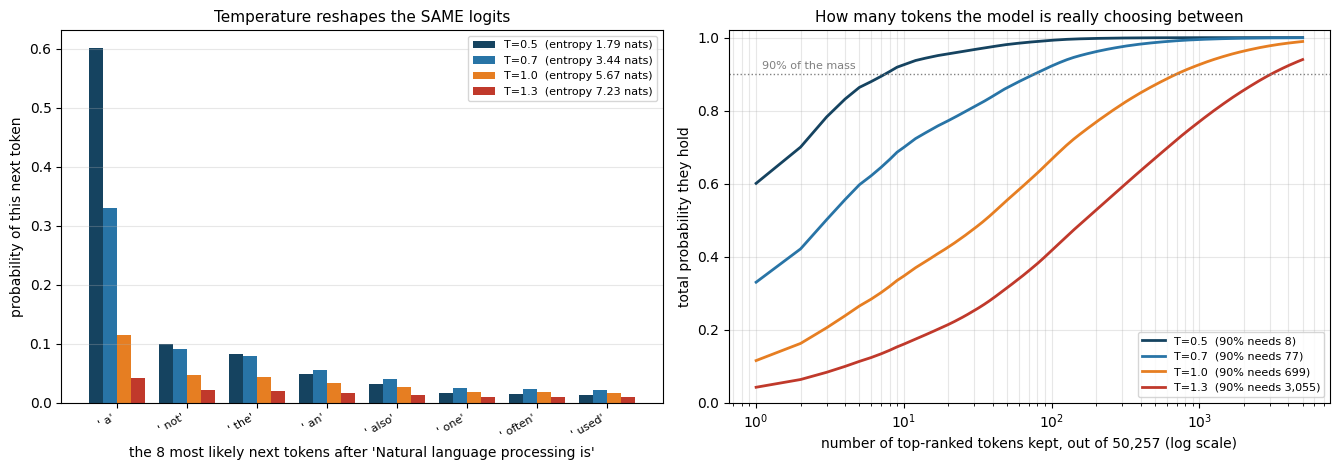

 temperature   P(top token)   entropy (nats)   tokens for 90%
--------------------------------------------------------------
         0.5          0.601             1.79                8
         0.7          0.330             3.44               77
         1.0          0.116             5.67              699
         1.3          0.042             7.23            3,055


In [4]:
# WHAT: one forward pass, four temperatures applied to the SAME logits.
# WHY: "temperature concentrates or flattens the distribution" is the sentence
# every LLM tutorial writes. This is the distribution, so you can check it.

import numpy as np
import matplotlib.pyplot as plt

if HAS_TRANSFORMERS:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM

    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    lm = AutoModelForCausalLM.from_pretrained("gpt2")
    lm.eval()

    prompt = "Natural language processing is"
    enc = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        next_logits = lm(**enc).logits[0, -1]        # scores for every token in the vocabulary
    vocab_n = next_logits.shape[0]

    TEMPS = [0.5, 0.7, 1.0, 1.3]
    COLS = ["#154360", "#2874a6", "#e67e22", "#c0392b"]
    base = torch.softmax(next_logits, dim=-1)
    top8 = torch.topk(base, 8)
    tok_labels = [repr(tokenizer.decode([i])) for i in top8.indices.tolist()]

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 4.8))
    bw = 0.2
    xs = np.arange(8)
    ranks = np.arange(1, 5001)
    k90 = {}
    for n, (T, c) in enumerate(zip(TEMPS, COLS)):
        probs_T = torch.softmax(next_logits / T, dim=-1)
        entropy = -(probs_T * torch.log(probs_T.clamp_min(1e-12))).sum().item()
        axL.bar(xs + (n - 1.5) * bw, probs_T[top8.indices].numpy(), bw, color=c,
                label=f"T={T}  (entropy {entropy:.2f} nats)")
        sorted_p = torch.sort(probs_T, descending=True).values
        cum = torch.cumsum(sorted_p, 0)
        k90[T] = int((cum >= 0.9).nonzero()[0]) + 1          # tokens needed to hold 90%
        axR.plot(ranks, cum[:5000].numpy(), color=c, lw=2, label=f"T={T}  (90% needs {k90[T]:,})")

    axL.set_xticks(xs, tok_labels, rotation=30, ha="right", fontsize=8)
    axL.set_ylabel("probability of this next token")
    axL.set_xlabel(f"the 8 most likely next tokens after {prompt!r}")
    axL.set_title("Temperature reshapes the SAME logits", fontsize=11)
    axL.legend(fontsize=8)
    axL.grid(axis="y", alpha=0.3)

    axR.set_xscale("log")
    axR.set_xlabel(f"number of top-ranked tokens kept, out of {vocab_n:,} (log scale)")
    axR.set_ylabel("total probability they hold")
    axR.set_ylim(0, 1.02)
    axR.axhline(0.9, color="grey", ls=":", lw=1)
    axR.text(1.1, 0.915, "90% of the mass", fontsize=8, color="grey")
    axR.set_title("How many tokens the model is really choosing between", fontsize=11)
    axR.legend(fontsize=8, loc="lower right")
    axR.grid(alpha=0.3, which="both")
    fig.tight_layout()
    plt.show()

    print(f"{'temperature':>12}{'P(top token)':>15}{'entropy (nats)':>17}{'tokens for 90%':>17}")
    print("-" * 62)
    for T in TEMPS:
        pT = torch.softmax(next_logits / T, dim=-1)
        ent = -(pT * torch.log(pT.clamp_min(1e-12))).sum().item()
        print(f"{T:>12}{pT.max().item():>15.3f}{ent:>17.2f}{k90[T]:>17,}")
else:
    print("Transformers unavailable — skipping the temperature measurement.")

**Read the left panel.** Eight bars per token, one group per candidate, four temperatures side by side.
The token `' a'` is the model's favourite at every temperature — temperature never changes the *ranking*.
What it changes is how concentrated the mass is: `' a'` holds **0.601** of the probability at T=0.5 and
only **0.042** at T=1.3 — a 14-fold collapse — while the runner-up `' not'` falls by less than 5×
(0.099 → 0.021). The probability the leader gives up does not move to the other seven bars; it drains into
the long tail of tokens too unlikely to appear in this panel at all. That is the whole mechanism: dividing
the logits by a bigger number pulls them closer together before the softmax.

**Read the right panel**, which is the same fact stated as a budget. Each curve answers "if I only allowed
the model to pick from its top *k* tokens, how much of its probability would I be keeping?" At **T=0.5, 8
tokens** carry 90% of the mass — the model is effectively choosing among eight words. At **T=1.0 it takes
699 tokens**, and at **T=1.3 it takes 3,055** out of a 50,257-token vocabulary. Raising the temperature
from 0.7 to 1.3 does not make the model more creative in any deep sense; it widens the pool of tokens it is
willing to draw from by a factor of forty. Everything you saw in the generated paragraphs follows from
that one number.

### Watching generation happen, one step at a time

Generation is a loop, and the paragraphs above are only its final output. Below we run the loop again and
record, **at every step**, the probability the model assigned to the token it actually emitted. Then we mark
the steps that ended up inside a phrase the model had already written — which is what "degeneration" looks
like when you count it rather than eyeball it.

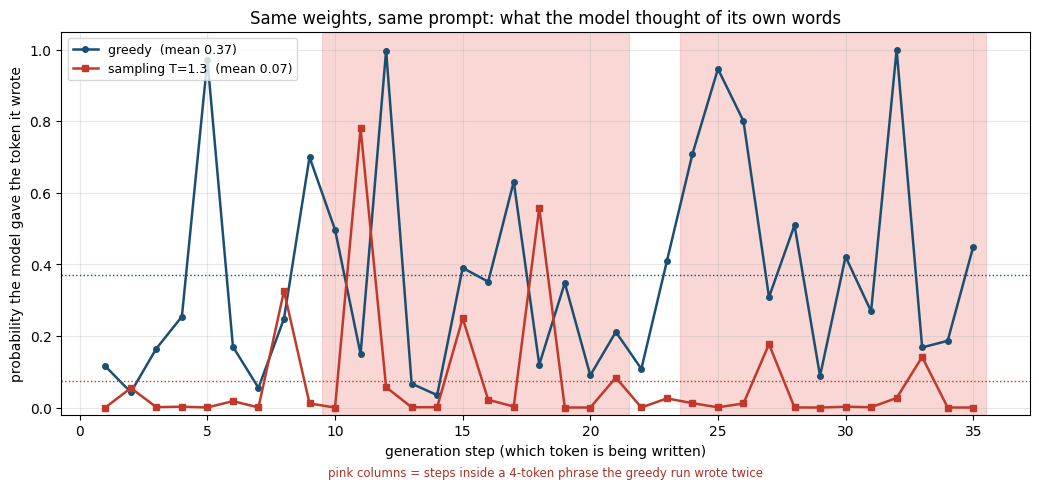

steps inside a repeated 4-token phrase — greedy: 24/35   |   sampling T=1.3: 0/35
mean probability of the chosen token — greedy: 0.371   |   sampling T=1.3: 0.073
steps where greedy was ≥ 0.90 certain: 4   |   where sampling was: 0

step  token            P(chosen)  repeated?
----------------------------------------------
   1  ' a'                 0.116  
   2  ' very'              0.043  
   3  ' important'         0.165  
   4  ' part'              0.254  
   5  ' of'                0.971  
   6  ' the'               0.170  
   7  ' language'          0.055  
   8  ' learning'          0.248  
   9  ' process'           0.699  
  10  '.'                  0.497  <-- repeat
  11  '\n'                 0.149  <-- repeat
  12  '\n'                 0.997  <-- repeat
  13  'The'                0.067  <-- repeat
  14  ' first'             0.035  <-- repeat
  15  ' step'              0.390  <-- repeat
  16  ' is'                0.351  <-- repeat
  17  ' to'                0.631  <-- repeat
 

In [5]:
# WHAT: re-run generation, capturing the per-step probability of the chosen token.
# WHY: greedy decoding fails in a specific, measurable way (Holtzman et al. 2020).
# Everything plotted here comes from the same GPT-2 that wrote the paragraphs above.

if HAS_TRANSFORMERS:
    def generate_with_steps(sample, temp=None, seed=42):
        """Return (token ids, per-step probability of the token that was chosen)."""
        if sample:
            set_seed(seed)
        kw = dict(max_new_tokens=35, output_scores=True,
                  return_dict_in_generate=True, pad_token_id=50256)
        kw.update(dict(do_sample=True, temperature=temp, top_k=0) if sample
                  else dict(do_sample=False))
        out = lm.generate(**enc, **kw)
        new_ids = out.sequences[0][enc["input_ids"].shape[1]:]
        step_p = [torch.softmax(s[0], dim=-1)[t].item() for s, t in zip(out.scores, new_ids)]
        return new_ids.tolist(), np.array(step_p)

    greedy_ids, greedy_p = generate_with_steps(sample=False)
    hot_ids, hot_p = generate_with_steps(sample=True, temp=1.3)

    def repeated_mask(ids, n=4):
        """True at every position inside an n-token phrase that occurs more than once."""
        m = np.zeros(len(ids), dtype=bool)
        for i in range(len(ids) - n + 1):
            for j in range(i + 1, len(ids) - n + 1):
                if ids[i:i + n] == ids[j:j + n]:
                    m[i:i + n] = True
                    m[j:j + n] = True
        return m

    rep_greedy = repeated_mask(greedy_ids)
    rep_hot = repeated_mask(hot_ids)
    steps_axis = np.arange(1, len(greedy_ids) + 1)

    fig, ax = plt.subplots(figsize=(10.5, 5.0))
    # pink = inside a repeated phrase; draw one span per contiguous run, not per step
    run_start = None
    for i in range(len(rep_greedy) + 1):
        flagged = i < len(rep_greedy) and rep_greedy[i]
        if flagged and run_start is None:
            run_start = i
        elif not flagged and run_start is not None:
            ax.axvspan(run_start + 0.5, i + 0.5, color="#f5b7b1", alpha=0.55, zorder=0)
            run_start = None
    ax.plot(steps_axis, greedy_p, marker="o", ms=4, color="#1b4f72", lw=1.8,
            label=f"greedy  (mean {greedy_p.mean():.2f})")
    ax.plot(steps_axis, hot_p, marker="s", ms=4, color="#c0392b", lw=1.8,
            label=f"sampling T=1.3  (mean {hot_p.mean():.2f})")
    ax.axhline(greedy_p.mean(), color="#1b4f72", ls=":", lw=1)
    ax.axhline(hot_p.mean(), color="#c0392b", ls=":", lw=1)
    ax.set_xlabel("generation step (which token is being written)")
    ax.set_ylabel("probability the model gave the token it wrote")
    ax.set_title("Same weights, same prompt: what the model thought of its own words")
    ax.set_ylim(-0.02, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")
    ax.text(0.5, -0.16, "pink columns = steps inside a 4-token phrase the greedy run wrote twice",
            transform=ax.transAxes, ha="center", fontsize=8.5, color="#a93226")
    fig.tight_layout()
    plt.show()

    print(f"steps inside a repeated 4-token phrase — greedy: {rep_greedy.sum()}/{len(greedy_ids)}"
          f"   |   sampling T=1.3: {rep_hot.sum()}/{len(hot_ids)}")
    print(f"mean probability of the chosen token — greedy: {greedy_p.mean():.3f}"
          f"   |   sampling T=1.3: {hot_p.mean():.3f}")
    print(f"steps where greedy was ≥ 0.90 certain: {(greedy_p >= 0.90).sum()}"
          f"   |   where sampling was: {(hot_p >= 0.90).sum()}\n")

    print(f"{'step':>4}  {'token':<16}{'P(chosen)':>10}  repeated?")
    print("-" * 46)
    for i, (tid, pr) in enumerate(zip(greedy_ids, greedy_p), start=1):
        print(f"{i:>4}  {tokenizer.decode([tid])!r:<16}{pr:>10.3f}  "
              f"{'<-- repeat' if rep_greedy[i-1] else ''}")
else:
    print("Transformers unavailable — skipping the step-by-step measurement.")

**Read the picture.** Every point is one generated token, placed at the probability the model itself gave
that token at the moment it wrote it. The dotted horizontal lines are the two means.

The blue greedy line sits far above the red sampled one almost everywhere: **mean 0.37 against 0.07**. It
is at least 90% certain at **4 of its 35 steps** and touches **1.000** at step 32, where GPT-2 had
effectively no alternative; the sampled run never once gets above 0.90. That is greedy decoding working
exactly as specified, and it is also the problem. The pink columns mark every step that landed inside a
4-token phrase the run had already produced: **24 of the greedy run's 35 steps**, against **0 of the
sampled run's**. The step table underneath shows the loop closing: `'The'`, `' first'`, `' step'` are
written at steps 13-15 and again at steps 33-35, more confidently the second time
(0.067 → 0.168, 0.035 → 0.186, 0.390 → 0.449).

This is Holtzman et al.'s point in one plot: maximising probability at every step does not produce
human-like text, it produces text that gets more and more certain of itself and less and less informative.
The red line is the opposite failure — the sampled run picks tokens it thought were near-impossible (many
points sit at 0.00) and pays for its variety with nonsense such as *"Prophe AC"*. Neither line is the
setting you would ship. Real systems live between them, with top-k or nucleus sampling, and now you can see
what the dial is actually turning.

## 💬 Discuss

Argue from the text GPT-2 actually generated above, not from what you have read about ChatGPT.

1. Greedy decoding produced *"The first step is to understand the language. The second step is to
   understand the language."* — the single most likely next token, over and over. Holtzman et al. named
   this *neural text degeneration* ([arXiv:1904.09751](https://arxiv.org/abs/1904.09751)). Explain in one
   sentence why *always choosing the most probable token* produces the *least* human-like text. Then say
   which decoding setting you would ship for (a) a legal-summary tool and (b) a marketing-copy assistant.
2. Compare your temperature 0.7 and 1.3 samples. Both are grammatical; at least one probably states
   something false. If fluency is unrelated to truthfulness, what signal is left for a **reader** to judge
   quality by — and what does that imply about putting generated text in front of customers unedited?
3. Air Canada's chatbot invented a refund policy and a tribunal made the airline honour the consequences.
   Where would you put the safeguard: filter the output, restrict the model to retrieved documents, keep a
   human approval step, or publish a disclaimer? Rank those four by **cost**, then by **how much each would
   actually have prevented that case**. Do the two rankings match?

## Part 3: Scaling Up — the OpenAI API (walkthrough, not executed)

GPT-4-class models are far too large to run locally; you reach them through an API. The concepts are the
ones you just used — a prompt, `max_tokens`, `temperature` — plus a chat message format.

⚠️ **This section is a code walkthrough only.** The cell below *prints* the code instead of running it,
because executing it needs an OpenAI account, an `OPENAI_API_KEY` environment variable, and paid credits.
If you have a key, paste the printed code into a new cell and run it.


In [6]:
# Walkthrough (NOT executed): the modern OpenAI chat-completions API pattern.
# The parameters mirror what you just used locally — model, max tokens,
# temperature — plus the system/user message format used by all chat LLMs.

print("=" * 70)
print("Modern OpenAI API usage (openai>=1.0) — WALKTHROUGH, not executed")
print("=" * 70)
print('''
    # 1. Install the client:      pip install openai
    # 2. Set your key (never hardcode it):
    #      export OPENAI_API_KEY="sk-..."

    from openai import OpenAI

    client = OpenAI()                      # reads OPENAI_API_KEY from the environment

    response = client.chat.completions.create(
        model="gpt-4o-mini",               # or another available chat model
        messages=[
            {"role": "system", "content": "You are a helpful NLP tutor."},
            {"role": "user",   "content": "Explain tokenization in two sentences."},
        ],
        max_tokens=100,
        temperature=0.7,
    )

    print(response.choices[0].message.content)
''')

print("Key parameters (same ideas you used with GPT-2 above):")
print("  - model:       which model answers (capability vs. cost trade-off)")
print("  - messages:    the conversation so far (system / user / assistant roles)")
print("  - max_tokens:  cap on the generated length")
print("  - temperature: 0 = focused/deterministic ... ~1 = balanced ... higher = adventurous")

print("\nPrompt engineering tips (apply to any LLM):")
print("  - Be specific about the task, audience, and output format")
print("  - Provide examples (few-shot prompting)")
print("  - Give the model a role via the system message")
print("  - Iterate: small prompt changes can change results a lot")

Modern OpenAI API usage (openai>=1.0) — WALKTHROUGH, not executed

    # 1. Install the client:      pip install openai
    # 2. Set your key (never hardcode it):
    #      export OPENAI_API_KEY="sk-..."

    from openai import OpenAI

    client = OpenAI()                      # reads OPENAI_API_KEY from the environment

    response = client.chat.completions.create(
        model="gpt-4o-mini",               # or another available chat model
        messages=[
            {"role": "system", "content": "You are a helpful NLP tutor."},
            {"role": "user",   "content": "Explain tokenization in two sentences."},
        ],
        max_tokens=100,
        temperature=0.7,
    )

    print(response.choices[0].message.content)

Key parameters (same ideas you used with GPT-2 above):
  - model:       which model answers (capability vs. cost trade-off)
  - messages:    the conversation so far (system / user / assistant roles)
  - max_tokens:  cap on the generated length
  - temperatu

## Summary

### What you actually did here
- Ran **real text generation with GPT-2 locally** — greedy decoding and sampling at temperatures 0.7 and 1.3
- Saw generation parameters (`max_new_tokens`, `temperature`, seeding) affect actual outputs
- Walked through (without executing) the modern OpenAI API call for GPT-4-class models

### Key Concepts
1. **Autoregressive generation**: GPT predicts one token at a time, left to right (the causal mask from the bridge notebook)
2. **Decoding strategy matters**: greedy is deterministic but repetitive; sampling + temperature trades predictability for creativity
3. **Local vs. API**: small open models (GPT-2) run on your machine; frontier models are reached through paid APIs, with the same core parameters
4. **Prompt engineering**: clear, specific, example-rich prompts get better completions

### Honest limitations
- GPT-2 is a 2019-era 124M-parameter model: fluent, but unreliable on facts — treat its output as a mechanism demo, not information
- The OpenAI section was **not executed** in this notebook; nothing here required an API key

**Reference:** Course 07, Unit 4: "Deep Learning for NLP" — GPT text generation practical content


## ⚠️ Where this breaks

**Fluency is not knowledge, and confidence is not calibration.** GPT-2 has 124M parameters and 2019
training data. It will state a wrong date in perfect English and give you no signal that it did. Nothing in
this notebook — not temperature, not seeding, not prompt wording — makes generated text *true*.

**Visible in your own output:** greedy decoding repeated itself within two sentences. That is not a fluke of
this run; it is what maximizing token probability does. Any deployment using greedy decoding for long
outputs will meet it.

**Reproducibility here is conditional.** `set_seed(42)` makes *sampling* reproducible on this machine, with
this library version, on this hardware. It is no guarantee across versions or devices, and it does not
exist at all for a hosted API — the same prompt to the same commercial model can return different text
tomorrow. Never write a test that asserts an exact generated string.

**When not to use a generative model:**
- The task has a fixed, checkable answer set (routing, classification, extraction) → a classifier (Unit 3)
  or NER (Unit 3, lesson 02) is cheaper, testable, and cannot invent an option that does not exist.
- The answer must come from *your* documents → do not fine-tune facts in; **retrieve** them and make the
  model quote its source (RAG, [arXiv:2005.11401](https://arxiv.org/abs/2005.11401)). Retrieval is also
  what makes an answer auditable after the fact.
- Anything with legal or medical consequence and no human in the loop → *Moffatt v. Air Canada* is now the
  cheapest available lesson on that point.

**One 2026 correction to Part 3.** A paid API is no longer the only route to a large model. Open-weight
releases with published model cards — gpt-oss ([arXiv:2508.10925](https://arxiv.org/abs/2508.10925)), the
Qwen3 family ([arXiv:2505.09388](https://arxiv.org/abs/2505.09388)) — run on local or on-premise hardware.
For a Saudi organization with data-residency obligations, "which model" and "whose servers" are the same
question, and this notebook's local GPT-2 run is the small version of that answer.

## 🔭 State of the field (2026)

GPT-2 *continues* text; the models your users have met *answer instructions*, and the distance between those
two behaviours is a training stage this notebook does not contain. InstructGPT (reference 4) opened it with
human feedback, and Direct Preference Optimization then removed the separate reward model and turned
preference training into a plain classification loss
([arXiv:2305.18290](https://arxiv.org/abs/2305.18290)) — which is how alignment went from a research project
to a step in a recipe. The second change is that decoding became a *budget*: since DeepSeek-R1 it is routine
to spend more compute per question, producing long deliberate reasoning trained by reinforcement learning
with checkable rewards ([arXiv:2501.12948](https://arxiv.org/abs/2501.12948)), and current open families
expose that as a mode you switch on per request
([arXiv:2505.09388](https://arxiv.org/abs/2505.09388)). Temperature is still underneath all of it, doing
exactly what you measured.

That is the reason to run the small model first. Every layer above sits on plain next-token prediction, and
the repetition under greedy decoding, the confident wrong fact, and the temperature curve you produced are
the base behaviour that instruction tuning and preference optimization are paid to *manage* — not to remove.
Seeing it unmanaged once is the difference between using a chat model and trusting one.


## 📚 References

The GPT lineage, the decoding-strategy paper behind the temperature experiments above, and the layers added since:

1. Radford, A., Wu, J., Child, R., et al. (2019). *Language Models are Unsupervised Multitask Learners* (GPT-2). OpenAI Technical Report.
2. Brown, T. B., Mann, B., Ryder, N., et al. (2020). *Language Models are Few-Shot Learners* (GPT-3). NeurIPS 2020. [arXiv:2005.14165](https://arxiv.org/abs/2005.14165)
3. Holtzman, A., Buys, J., Du, L., Forbes, M., & Choi, Y. (2020). *The Curious Case of Neural Text Degeneration*. ICLR 2020. [arXiv:1904.09751](https://arxiv.org/abs/1904.09751)
4. Ouyang, L., Wu, J., Jiang, X., et al. (2022). *Training Language Models to Follow Instructions with Human Feedback* (InstructGPT). NeurIPS 2022. [arXiv:2203.02155](https://arxiv.org/abs/2203.02155)
5. Rafailov, R., Sharma, A., Mitchell, E., Ermon, S., Manning, C. D., & Finn, C. (2023). *Direct Preference Optimization: Your Language Model is Secretly a Reward Model*. [arXiv:2305.18290](https://arxiv.org/abs/2305.18290) — preference training without a separate reward model; the standard teaching example for alignment.
6. DeepSeek-AI (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning*. [arXiv:2501.12948](https://arxiv.org/abs/2501.12948) — long deliberate reasoning produced by reinforcement learning rather than by prompting.
7. Yang, A., Li, A., Yang, B., Zhang, B., Hui, B., et al. (2025). *Qwen3 Technical Report*. [arXiv:2505.09388](https://arxiv.org/abs/2505.09388) — thinking and non-thinking as switchable modes of one open model family.
8. OpenAI (2025). *gpt-oss-120b & gpt-oss-20b Model Card*. [arXiv:2508.10925](https://arxiv.org/abs/2508.10925) — an open-weight release with a published card, so the whole stack can be inspected rather than called.
